JST: 1914-01-12 10:00:00+09:00 UTC: 1914-01-12 01:00:00 USE(3h): 1914-01-12 00:00:00
saved: csv/20cr_sakurajima_19140112_00UTC.csv


/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_12723/2067752241.py:167: RuntimeWarning: invalid value encountered in sqrt
  def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))


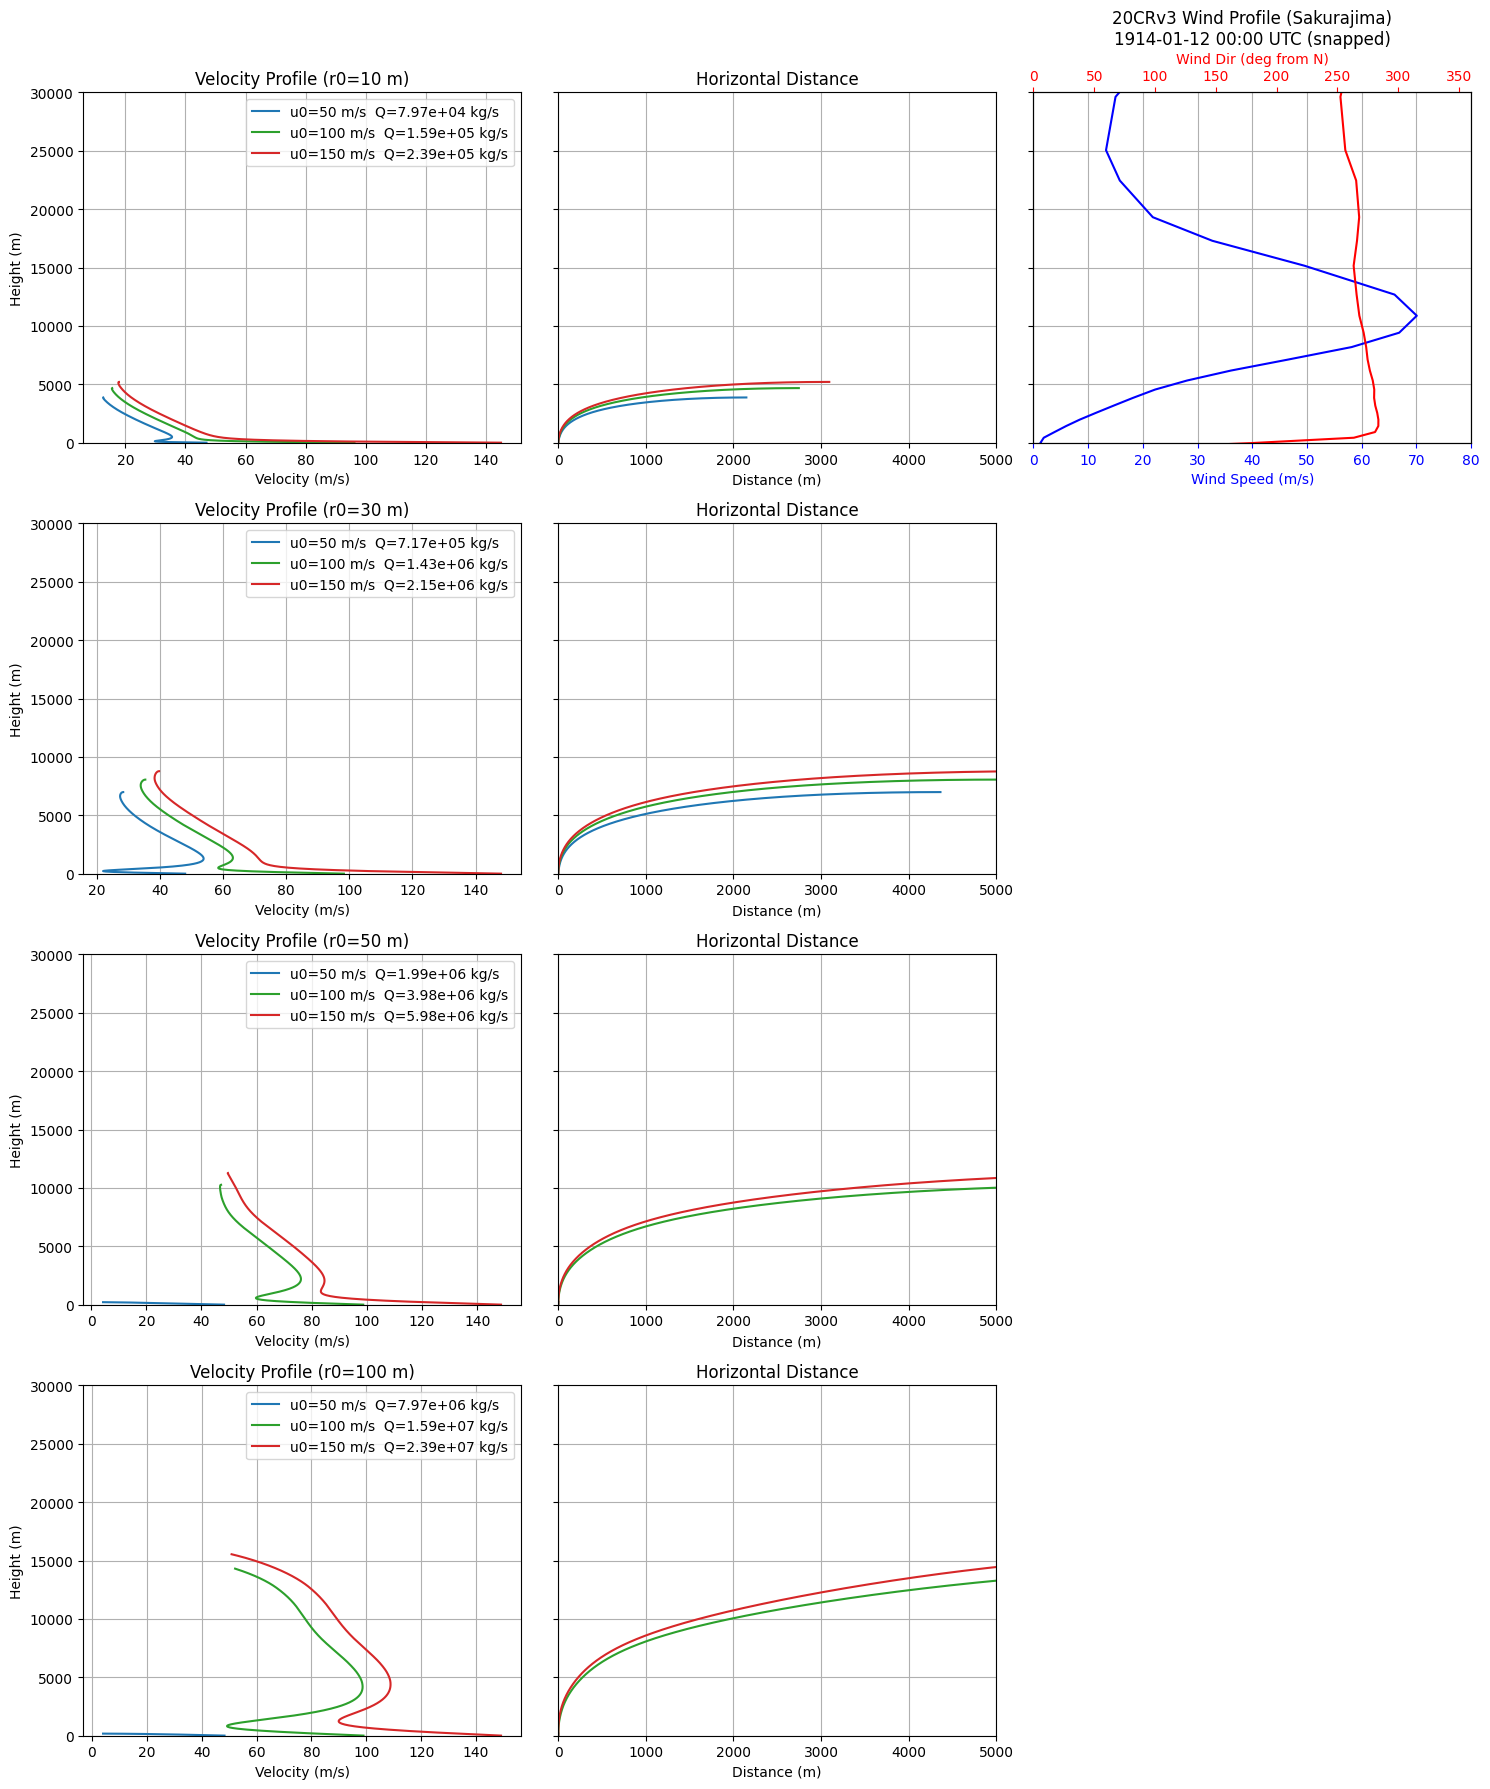

saved: png/plume_sakurajima_19140112_00UTC_20cr.png


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
import os

os.makedirs("csv", exist_ok=True)
os.makedirs("png", exist_ok=True)

# =========================
# 0) 設定：Sakurajima 1914（例）
# =========================
# 火口位置（代表値）・標高（代表値 1117 m）
lat0, lon0 = 31.583, 130.650
height = 1117.0  # m（必要なら南岳火口などに合わせて変更）

# 噴火時刻（JSTで与える→UTCへ）
jst = timezone(timedelta(hours=9))
t_jst = datetime(1914, 1, 12, 10, 0, tzinfo=jst)
t_utc = t_jst.astimezone(timezone.utc).replace(tzinfo=None)

# 20CRv3 は 3時間毎（00,03,...）なので近い時刻に丸める
def snap_to_3h(dt):
    h = dt.hour
    hh = int(round(h/3)*3) % 24
    return dt.replace(hour=hh, minute=0, second=0, microsecond=0)

t_use = snap_to_3h(t_utc)
year = t_use.year
date_str = t_use.strftime("%Y%m%d")
hour_str = t_use.strftime("%H")
target_date = t_use.strftime("%Y-%m-%d")
target_time = t_use.strftime("%H:%M")

print("JST:", t_jst, "UTC:", t_utc, "USE(3h):", t_use)

# =========================
# 1) 20CRv3 (NOAA PSL THREDDS) から読む
#    1914 は prsSI（sub-daily）を使う
# =========================
base = "https://psl.noaa.gov/thredds/dodsC/Datasets/20thC_ReanV3/prsSI"
# 20CRv3 のファイル命名（年ごと）
urls = {
    "u":   f"{base}/uwnd.{year}.nc",
    "v":   f"{base}/vwnd.{year}.nc",
    "air": f"{base}/air.{year}.nc",
    "hgt": f"{base}/hgt.{year}.nc",
}

# lazyで開いて必要部分だけ取りに行く
dsu = xr.open_dataset(urls["u"])
dsv = xr.open_dataset(urls["v"])
dst = xr.open_dataset(urls["air"])
dsh = xr.open_dataset(urls["hgt"])

# 変数名（ファイル側の標準名に依存）
# uwnd/vwnd/air/hgt という変数が入っている想定
# 座標は time, level(hPa), lat, lon が一般的
u_da   = dsu[list(dsu.data_vars)[0]]
v_da   = dsv[list(dsv.data_vars)[0]]
T_da   = dst[list(dst.data_vars)[0]]
hgt_da = dsh[list(dsh.data_vars)[0]]

# 最近傍の格子点 & 指定時刻（存在しない場合は nearest）
pt_u = u_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")
pt_v = v_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")
pt_T = T_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")
pt_h = hgt_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")

# pressure levels（座標名が level の想定）
plev_name = "level" if "level" in pt_u.coords else list(pt_u.coords)[0]
pressure = np.ravel(pt_u[plev_name].values).astype(float)   # hPa
u = np.ravel(pt_u.values)
v = np.ravel(pt_v.values)
T = np.ravel(pt_T.values)                                  # K
altitude = np.ravel(pt_h.values)                           # hgt: m（ジオポテンシャル高度）

# 風速・風向（気象の慣例：風向 = 風が“吹いてくる方角”）
wind_speed = np.sqrt(u**2 + v**2)
wind_dir = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

df = pd.DataFrame({
    "Pressure_hPa": pressure,
    "Altitude_m": altitude,
    "WindSpeed_mps": wind_speed,
    "WindDirection_deg": wind_dir,
    "Temperature_K": T
}).sort_values("Altitude_m").reset_index(drop=True)

# 保存（確認用）
csv_out = f"csv/20cr_sakurajima_{date_str}_{hour_str}UTC.csv"
df.to_csv(csv_out, index=False)
print("saved:", csv_out)

# =========================
# 2) 火口基準 z_rel と補間（端は固定で安定化）
# =========================
df["z_rel_m"] = df["Altitude_m"] - height
df = df.sort_values("z_rel_m").drop_duplicates(subset="z_rel_m").reset_index(drop=True)

# --- z=0 アンカー（近傍の2点から線形補間で作成、無ければ追加） ---
if not np.any(np.isclose(df["z_rel_m"].values, 0.0, atol=1e-6)):
    df_neg = df[df["z_rel_m"] < 0].copy()
    df_pos = df[df["z_rel_m"] > 0].copy()
    if (len(df_neg) > 0) and (len(df_pos) > 0):
        a = df_neg.iloc[df_neg["z_rel_m"].values.argmax()]  # 0に最も近い負
        b = df_pos.iloc[df_pos["z_rel_m"].values.argmin()]  # 0に最も近い正
        za, zb = float(a["z_rel_m"]), float(b["z_rel_m"])
        w = (0.0 - za) / (zb - za)
        lin = lambda xa, xb: float(xa + (xb - xa) * w)

        anchor = {
            "Pressure_hPa":      lin(a["Pressure_hPa"], b["Pressure_hPa"]),
            "Altitude_m":        height,
            "WindSpeed_mps":     lin(a["WindSpeed_mps"], b["WindSpeed_mps"]),
            "WindDirection_deg": lin(a["WindDirection_deg"], b["WindDirection_deg"]),
            "Temperature_K":     lin(a["Temperature_K"], b["Temperature_K"]),
            "z_rel_m":           0.0
        }
        df = pd.concat([df, pd.DataFrame([anchor])], ignore_index=True).sort_values("z_rel_m").reset_index(drop=True)

# 端固定（外挿で暴れないように）
vmin, vmax = float(df["WindSpeed_mps"].iloc[0]), float(df["WindSpeed_mps"].iloc[-1])
Tmin, Tmax = float(df["Temperature_K"].iloc[0]), float(df["Temperature_K"].iloc[-1])
pmin, pmax = float(df["Pressure_hPa"].iloc[0])*100.0, float(df["Pressure_hPa"].iloc[-1])*100.0

v_interp = interp1d(df["z_rel_m"], df["WindSpeed_mps"], bounds_error=False, fill_value=(vmin, vmax))
T_interp = interp1d(df["z_rel_m"], df["Temperature_K"], bounds_error=False, fill_value=(Tmin, Tmax))
p_interp = interp1d(df["z_rel_m"], df["Pressure_hPa"]*100.0, bounds_error=False, fill_value=(pmin, pmax))

def v_of_z(z): return float(v_interp(z))
def tempa(z):  return float(T_interp(z))
def p(z):      return float(p_interp(z))

# =========================
# 3) 噴煙モデル（あなたの式をそのまま）
# =========================
n0 = 0.03
T0 = 1273.0
theta0 = np.deg2rad(90.0)
ke, kw = 0.06, 0.2
pi, g = np.pi, 9.8
rga, rgv = 285.0, 462.0
cpm, cpa = 1000.0, 1000.0
rhol = 2.5e3

pa = p(0)
nv = n0
z_stop = float(df["z_rel_m"].max())  # 気象場の上端で止める

def rhoa(z): return p(z) / (rga * tempa(z))
def na(z, y1, Q): return 1.0 - Q / (pi * y1) if z > 0 else 0.0
def rg(z, y1, Q):
    na_ = na(z, y1, Q)
    return (na_ * rga + nv * (1 - na_) * rgv) / (na_ + nv * (1 - na_))
def cp(z, y1, Q): return na(z, y1, Q) * cpa + (1 - na(z, y1, Q)) * cpm
def temp(z, y1, y2, y3, Q):
    return 1.0 / cp(z, y1, Q) * (y3 / y1 - 0.5 * (y2 / y1)**2 - g * z)

def rho(z, y1, y2, y3, Q):
    na_ = na(z, y1, Q)
    return (((na_ + nv * (1 - na_)) * rg(z, y1, Q) * temp(z, y1, y2, y3, Q) / p(z))
            + (1 - na_) * (1 - nv) / rhol) ** (-1)

def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))
def uke(z, y1, y2, y4, Q):
    u_val = y2 / y1
    return ke * abs(u_val - v_of_z(z) * np.cos(y4)) + kw * abs(v_of_z(z) * np.sin(y4))

def f_vec(s, z, y, Q):
    y1, y2, y3, y4 = y
    r_ = r(z, y1, y2, y3, Q)
    rho_ = rho(z, y1, y2, y3, Q)
    rhoa_ = rhoa(z)
    uke_ = uke(z, y1, y2, y4, Q)
    f1 = 2 * uke_ * r_ * rhoa_
    f2 = r_**2 * (rhoa_ - rho_) * g * np.sin(y4) + v_of_z(z) * np.cos(y4) * f1
    f3 = (cpa * tempa(z) + g * z) * f1
    f4 = (r_**2 * (rhoa_ - rho_) * g * np.cos(y4) - v_of_z(z) * np.sin(y4) * f1) / y2
    return np.array([f1, f2, f3, f4])

r0_list = [10.0, 30.0, 50.0, 100.0]
u0_list = [50, 100, 150]
results_by_r0 = {}

for r0 in r0_list:
    results = {}
    for u0 in u0_list:
        rho0 = (nv * rgv * T0 / pa + (1 - nv) / rhol)**(-1)
        Q = rho0 * u0 * pi * r0**2
        y1 = Q / pi
        y2 = y1 * u0
        y3 = y1 * (cpm * T0 + u0**2 / 2)
        y4 = theta0
        y = np.array([y1, y2, y3, y4])

        s, z, x = 0.0, 0.0, 0.0
        ds_step = 10.0
        z_list, u_list, x_list = [], [], []

        for _ in range(10000):
            k1 = ds_step * f_vec(s, z, y, Q)
            k2 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k1/2, Q)
            k3 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k2/2, Q)
            k4 = ds_step * f_vec(s + ds_step, z + np.sin(y4)*ds_step, y + k3, Q)
            y_new = y + (k1 + 2*k2 + 2*k3 + k4) / 6

            z += ds_step * np.sin(y4)
            x += ds_step * np.cos(y4)
            y = y_new
            y4 = y[3]
            s += ds_step

            u_val = y[1] / y[0]
            z_list.append(z); u_list.append(u_val); x_list.append(x)

            if np.degrees(y4) <= 0 or z > min(30000, z_stop):
                break

        results[u0] = {"z": z_list, "u": u_list, "x": x_list, "Q": Q}
    results_by_r0[r0] = results

# =========================
# 4) プロット
# =========================
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 18), sharey=True)
colors = ['tab:blue', 'tab:green', 'tab:red']

for i, r0 in enumerate(r0_list):
    for j, u0 in enumerate(u0_list):
        Q = results_by_r0[r0][u0]["Q"]
        label = f"u0={u0} m/s  Q={Q:.2e} kg/s"
        axs[i, 0].plot(results_by_r0[r0][u0]["u"], results_by_r0[r0][u0]["z"], label=label, color=colors[j])
        axs[i, 1].plot(results_by_r0[r0][u0]["x"], results_by_r0[r0][u0]["z"], color=colors[j])

    axs[i, 0].set_ylabel("Height (m)")
    axs[i, 0].set_xlabel("Velocity (m/s)")
    axs[i, 0].set_title(f"Velocity Profile (r0={int(r0)} m)")
    axs[i, 0].legend(); axs[i, 0].grid(True)

    axs[i, 1].set_title("Horizontal Distance")
    axs[i, 1].set_xlabel("Distance (m)")
    axs[i, 1].set_xlim(0, 5000); axs[i, 1].grid(True)

ax3 = axs[0, 2]
ax3_tw = ax3.twiny()
ax3.plot(df["WindSpeed_mps"], df["z_rel_m"], 'b')
ax3.set_xlabel("Wind Speed (m/s)", color='b')
ax3.tick_params(axis='x', colors='b')
ax3.set_xlim(0, 80)
ax3.set_title(f"20CRv3 Wind Profile (Sakurajima)\n{target_date} {target_time} UTC (snapped)")
ax3.grid(True)

ax3_tw.plot(df["WindDirection_deg"], df["z_rel_m"], 'r')
ax3_tw.set_xlabel("Wind Dir (deg from N)", color='r')
ax3_tw.tick_params(axis='x', colors='r')
ax3_tw.set_xlim(0, 360)

axs[1, 2].axis('off'); axs[2, 2].axis('off'); axs[3, 2].axis('off')

for i in range(4):
    for j in range(2):
        axs[i, j].set_ylim(0, 30000)

plt.tight_layout()
outpng = f"png/plume_sakurajima_{date_str}_{hour_str}UTC_20cr.png"
plt.savefig(outpng, dpi=300)
plt.show()
print("saved:", outpng)


JST: 1914-01-12 10:00:00+09:00 UTC: 1914-01-12 01:00:00 USE(3h): 1914-01-12 00:00:00
saved: csv/20cr_sakurajima_19140112_00UTC.csv


/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_12723/1155521818.py:167: RuntimeWarning: invalid value encountered in sqrt
  def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))


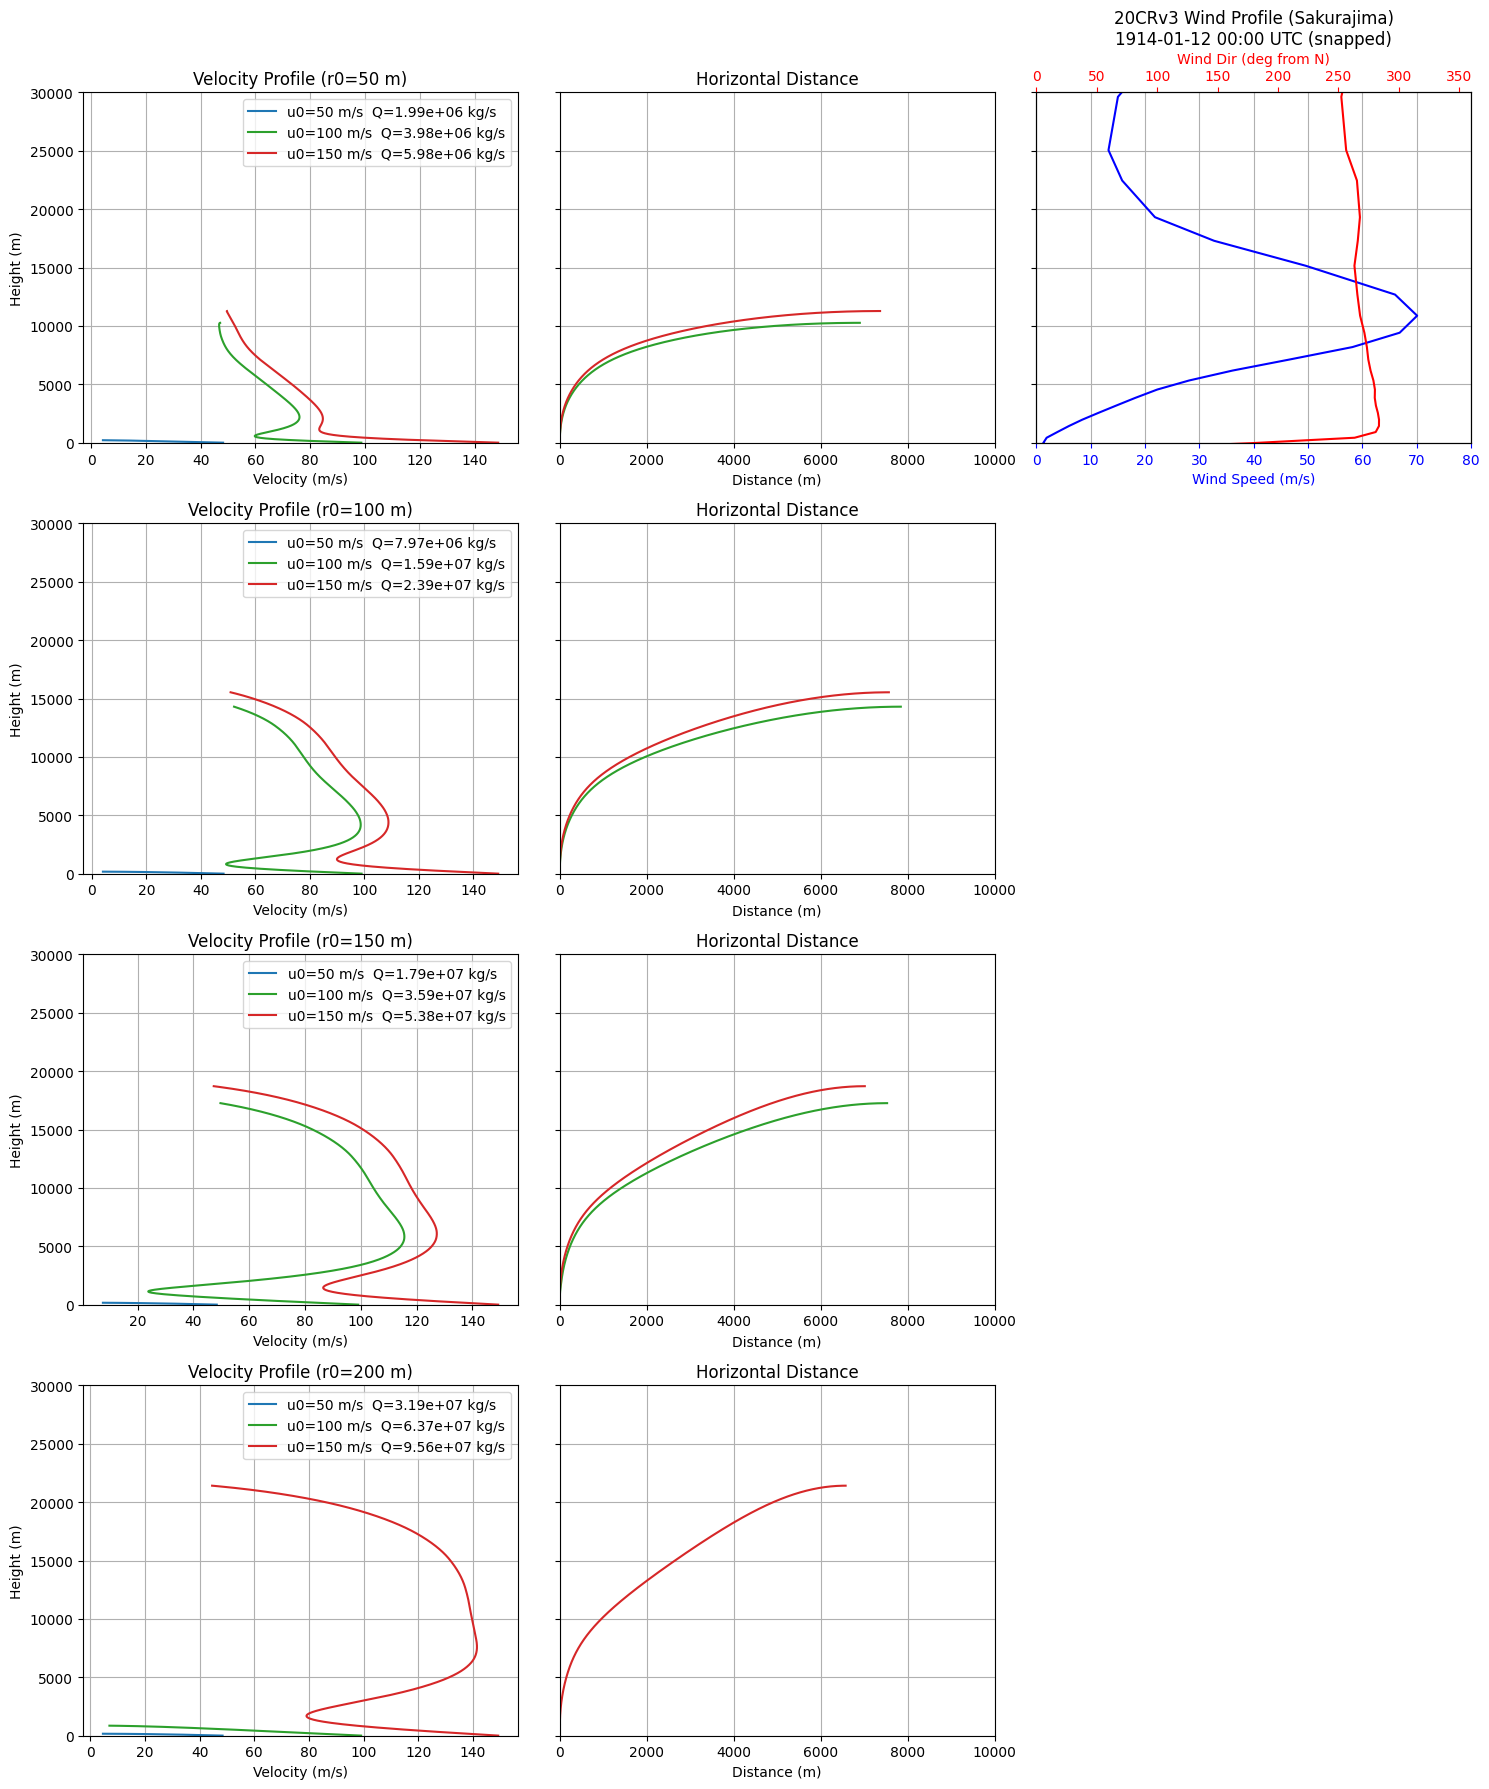

saved: png/plume_sakurajima_19140112_00UTC_20cr.png


In [6]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
import os

os.makedirs("csv", exist_ok=True)
os.makedirs("png", exist_ok=True)

# =========================
# 0) 設定：Sakurajima 1914（例）
# =========================
# 火口位置（代表値）・標高（代表値 1117 m）
lat0, lon0 = 31.583, 130.650
height = 1117.0  # m（必要なら南岳火口などに合わせて変更）

# 噴火時刻（JSTで与える→UTCへ）
jst = timezone(timedelta(hours=9))
t_jst = datetime(1914, 1, 12, 10, 0, tzinfo=jst)
t_utc = t_jst.astimezone(timezone.utc).replace(tzinfo=None)

# 20CRv3 は 3時間毎（00,03,...）なので近い時刻に丸める
def snap_to_3h(dt):
    h = dt.hour
    hh = int(round(h/3)*3) % 24
    return dt.replace(hour=hh, minute=0, second=0, microsecond=0)

t_use = snap_to_3h(t_utc)
year = t_use.year
date_str = t_use.strftime("%Y%m%d")
hour_str = t_use.strftime("%H")
target_date = t_use.strftime("%Y-%m-%d")
target_time = t_use.strftime("%H:%M")

print("JST:", t_jst, "UTC:", t_utc, "USE(3h):", t_use)

# =========================
# 1) 20CRv3 (NOAA PSL THREDDS) から読む
#    1914 は prsSI（sub-daily）を使う
# =========================
base = "https://psl.noaa.gov/thredds/dodsC/Datasets/20thC_ReanV3/prsSI"
# 20CRv3 のファイル命名（年ごと）
urls = {
    "u":   f"{base}/uwnd.{year}.nc",
    "v":   f"{base}/vwnd.{year}.nc",
    "air": f"{base}/air.{year}.nc",
    "hgt": f"{base}/hgt.{year}.nc",
}

# lazyで開いて必要部分だけ取りに行く
dsu = xr.open_dataset(urls["u"])
dsv = xr.open_dataset(urls["v"])
dst = xr.open_dataset(urls["air"])
dsh = xr.open_dataset(urls["hgt"])

# 変数名（ファイル側の標準名に依存）
# uwnd/vwnd/air/hgt という変数が入っている想定
# 座標は time, level(hPa), lat, lon が一般的
u_da   = dsu[list(dsu.data_vars)[0]]
v_da   = dsv[list(dsv.data_vars)[0]]
T_da   = dst[list(dst.data_vars)[0]]
hgt_da = dsh[list(dsh.data_vars)[0]]

# 最近傍の格子点 & 指定時刻（存在しない場合は nearest）
pt_u = u_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")
pt_v = v_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")
pt_T = T_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")
pt_h = hgt_da.sel(time=t_use, method="nearest").sel(lat=lat0, lon=lon0, method="nearest")

# pressure levels（座標名が level の想定）
plev_name = "level" if "level" in pt_u.coords else list(pt_u.coords)[0]
pressure = np.ravel(pt_u[plev_name].values).astype(float)   # hPa
u = np.ravel(pt_u.values)
v = np.ravel(pt_v.values)
T = np.ravel(pt_T.values)                                  # K
altitude = np.ravel(pt_h.values)                           # hgt: m（ジオポテンシャル高度）

# 風速・風向（気象の慣例：風向 = 風が“吹いてくる方角”）
wind_speed = np.sqrt(u**2 + v**2)
wind_dir = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

df = pd.DataFrame({
    "Pressure_hPa": pressure,
    "Altitude_m": altitude,
    "WindSpeed_mps": wind_speed,
    "WindDirection_deg": wind_dir,
    "Temperature_K": T
}).sort_values("Altitude_m").reset_index(drop=True)

# 保存（確認用）
csv_out = f"csv/20cr_sakurajima_{date_str}_{hour_str}UTC.csv"
df.to_csv(csv_out, index=False)
print("saved:", csv_out)

# =========================
# 2) 火口基準 z_rel と補間（端は固定で安定化）
# =========================
df["z_rel_m"] = df["Altitude_m"] - height
df = df.sort_values("z_rel_m").drop_duplicates(subset="z_rel_m").reset_index(drop=True)

# --- z=0 アンカー（近傍の2点から線形補間で作成、無ければ追加） ---
if not np.any(np.isclose(df["z_rel_m"].values, 0.0, atol=1e-6)):
    df_neg = df[df["z_rel_m"] < 0].copy()
    df_pos = df[df["z_rel_m"] > 0].copy()
    if (len(df_neg) > 0) and (len(df_pos) > 0):
        a = df_neg.iloc[df_neg["z_rel_m"].values.argmax()]  # 0に最も近い負
        b = df_pos.iloc[df_pos["z_rel_m"].values.argmin()]  # 0に最も近い正
        za, zb = float(a["z_rel_m"]), float(b["z_rel_m"])
        w = (0.0 - za) / (zb - za)
        lin = lambda xa, xb: float(xa + (xb - xa) * w)

        anchor = {
            "Pressure_hPa":      lin(a["Pressure_hPa"], b["Pressure_hPa"]),
            "Altitude_m":        height,
            "WindSpeed_mps":     lin(a["WindSpeed_mps"], b["WindSpeed_mps"]),
            "WindDirection_deg": lin(a["WindDirection_deg"], b["WindDirection_deg"]),
            "Temperature_K":     lin(a["Temperature_K"], b["Temperature_K"]),
            "z_rel_m":           0.0
        }
        df = pd.concat([df, pd.DataFrame([anchor])], ignore_index=True).sort_values("z_rel_m").reset_index(drop=True)

# 端固定（外挿で暴れないように）
vmin, vmax = float(df["WindSpeed_mps"].iloc[0]), float(df["WindSpeed_mps"].iloc[-1])
Tmin, Tmax = float(df["Temperature_K"].iloc[0]), float(df["Temperature_K"].iloc[-1])
pmin, pmax = float(df["Pressure_hPa"].iloc[0])*100.0, float(df["Pressure_hPa"].iloc[-1])*100.0

v_interp = interp1d(df["z_rel_m"], df["WindSpeed_mps"], bounds_error=False, fill_value=(vmin, vmax))
T_interp = interp1d(df["z_rel_m"], df["Temperature_K"], bounds_error=False, fill_value=(Tmin, Tmax))
p_interp = interp1d(df["z_rel_m"], df["Pressure_hPa"]*100.0, bounds_error=False, fill_value=(pmin, pmax))

def v_of_z(z): return float(v_interp(z))
def tempa(z):  return float(T_interp(z))
def p(z):      return float(p_interp(z))

# =========================
# 3) 噴煙モデル（あなたの式をそのまま）
# =========================
n0 = 0.03
T0 = 1273.0
theta0 = np.deg2rad(90.0)
ke, kw = 0.06, 0.2
pi, g = np.pi, 9.8
rga, rgv = 285.0, 462.0
cpm, cpa = 1000.0, 1000.0
rhol = 2.5e3

pa = p(0)
nv = n0
z_stop = float(df["z_rel_m"].max())  # 気象場の上端で止める

def rhoa(z): return p(z) / (rga * tempa(z))
def na(z, y1, Q): return 1.0 - Q / (pi * y1) if z > 0 else 0.0
def rg(z, y1, Q):
    na_ = na(z, y1, Q)
    return (na_ * rga + nv * (1 - na_) * rgv) / (na_ + nv * (1 - na_))
def cp(z, y1, Q): return na(z, y1, Q) * cpa + (1 - na(z, y1, Q)) * cpm
def temp(z, y1, y2, y3, Q):
    return 1.0 / cp(z, y1, Q) * (y3 / y1 - 0.5 * (y2 / y1)**2 - g * z)

def rho(z, y1, y2, y3, Q):
    na_ = na(z, y1, Q)
    return (((na_ + nv * (1 - na_)) * rg(z, y1, Q) * temp(z, y1, y2, y3, Q) / p(z))
            + (1 - na_) * (1 - nv) / rhol) ** (-1)

def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))
def uke(z, y1, y2, y4, Q):
    u_val = y2 / y1
    return ke * abs(u_val - v_of_z(z) * np.cos(y4)) + kw * abs(v_of_z(z) * np.sin(y4))

def f_vec(s, z, y, Q):
    y1, y2, y3, y4 = y
    r_ = r(z, y1, y2, y3, Q)
    rho_ = rho(z, y1, y2, y3, Q)
    rhoa_ = rhoa(z)
    uke_ = uke(z, y1, y2, y4, Q)
    f1 = 2 * uke_ * r_ * rhoa_
    f2 = r_**2 * (rhoa_ - rho_) * g * np.sin(y4) + v_of_z(z) * np.cos(y4) * f1
    f3 = (cpa * tempa(z) + g * z) * f1
    f4 = (r_**2 * (rhoa_ - rho_) * g * np.cos(y4) - v_of_z(z) * np.sin(y4) * f1) / y2
    return np.array([f1, f2, f3, f4])

r0_list = [50.0, 100.0, 150.0, 200.0]
u0_list = [50, 100, 150]
results_by_r0 = {}

for r0 in r0_list:
    results = {}
    for u0 in u0_list:
        rho0 = (nv * rgv * T0 / pa + (1 - nv) / rhol)**(-1)
        Q = rho0 * u0 * pi * r0**2
        y1 = Q / pi
        y2 = y1 * u0
        y3 = y1 * (cpm * T0 + u0**2 / 2)
        y4 = theta0
        y = np.array([y1, y2, y3, y4])

        s, z, x = 0.0, 0.0, 0.0
        ds_step = 10.0
        z_list, u_list, x_list = [], [], []

        for _ in range(10000):
            k1 = ds_step * f_vec(s, z, y, Q)
            k2 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k1/2, Q)
            k3 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k2/2, Q)
            k4 = ds_step * f_vec(s + ds_step, z + np.sin(y4)*ds_step, y + k3, Q)
            y_new = y + (k1 + 2*k2 + 2*k3 + k4) / 6

            z += ds_step * np.sin(y4)
            x += ds_step * np.cos(y4)
            y = y_new
            y4 = y[3]
            s += ds_step

            u_val = y[1] / y[0]
            z_list.append(z); u_list.append(u_val); x_list.append(x)

            if np.degrees(y4) <= 0 or z > min(30000, z_stop):
                break

        results[u0] = {"z": z_list, "u": u_list, "x": x_list, "Q": Q}
    results_by_r0[r0] = results

# =========================
# 4) プロット
# =========================
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 18), sharey=True)
colors = ['tab:blue', 'tab:green', 'tab:red']

for i, r0 in enumerate(r0_list):
    for j, u0 in enumerate(u0_list):
        Q = results_by_r0[r0][u0]["Q"]
        label = f"u0={u0} m/s  Q={Q:.2e} kg/s"
        axs[i, 0].plot(results_by_r0[r0][u0]["u"], results_by_r0[r0][u0]["z"], label=label, color=colors[j])
        axs[i, 1].plot(results_by_r0[r0][u0]["x"], results_by_r0[r0][u0]["z"], color=colors[j])

    axs[i, 0].set_ylabel("Height (m)")
    axs[i, 0].set_xlabel("Velocity (m/s)")
    axs[i, 0].set_title(f"Velocity Profile (r0={int(r0)} m)")
    axs[i, 0].legend(); axs[i, 0].grid(True)

    axs[i, 1].set_title("Horizontal Distance")
    axs[i, 1].set_xlabel("Distance (m)")
    axs[i, 1].set_xlim(0, 10000); axs[i, 1].grid(True)

ax3 = axs[0, 2]
ax3_tw = ax3.twiny()
ax3.plot(df["WindSpeed_mps"], df["z_rel_m"], 'b')
ax3.set_xlabel("Wind Speed (m/s)", color='b')
ax3.tick_params(axis='x', colors='b')
ax3.set_xlim(0, 80)
ax3.set_title(f"20CRv3 Wind Profile (Sakurajima)\n{target_date} {target_time} UTC (snapped)")
ax3.grid(True)

ax3_tw.plot(df["WindDirection_deg"], df["z_rel_m"], 'r')
ax3_tw.set_xlabel("Wind Dir (deg from N)", color='r')
ax3_tw.tick_params(axis='x', colors='r')
ax3_tw.set_xlim(0, 360)

axs[1, 2].axis('off'); axs[2, 2].axis('off'); axs[3, 2].axis('off')

for i in range(4):
    for j in range(2):
        axs[i, j].set_ylim(0, 30000)

plt.tight_layout()
outpng = f"png/plume_sakurajima_{date_str}_{hour_str}UTC_20cr.png"
plt.savefig(outpng, dpi=300)
plt.show()
print("saved:", outpng)
